# Customer Behavior Analytics & Churn Prediction Dashboard

## Task Information
- Task ID: DA-INT-1
- Domain: Data Analytics
- Organization: TEYZIX CORE Internship Program

## Project Objective
The objective of this project is to analyze customer behavior patterns and predict customer churn using machine learning techniques. The project transforms raw customer data into actionable business insights by performing exploratory data analysis, feature engineering, customer segmentation, visualization, and predictive modeling.

## Business Problem
Customer churn is one of the biggest challenges faced by subscription-based companies. Losing existing customers results in reduced revenue and increased customer acquisition costs. Therefore, organizations need data-driven solutions to identify customers who are likely to leave and take preventive actions.

## Project Goals
1. Analyze customer demographics and service usage patterns.
2. Identify factors influencing customer churn.
3. Engineer meaningful behavioral features.
4. Segment customers based on value and spending behavior.
5. Build machine learning models to predict churn probability.
6. Generate business insights and recommendations for customer retention.

## Dataset
The dataset used is the Telco Customer Churn Dataset, containing customer demographic information, service subscriptions, billing information, and churn status.

## Tools & Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Google Colab

Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

 Load Dataset

In [4]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [5]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 7043
Columns: 21


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


check for missing values

In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [13]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].unique())


customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender
['Female' 'Male']

Partner
['Yes' 'No']

Dependents
['No' 'Yes']

PhoneService
['No' 'Yes']

MultipleLines
['No phone service' 'No' 'Yes']

InternetService
['DSL' 'Fiber optic' 'No']

OnlineSecurity
['No' 'Yes' 'No internet service']

OnlineBackup
['Yes' 'No' 'No internet service']

DeviceProtection
['No' 'Yes' 'No internet service']

TechSupport
['No' 'Yes' 'No internet service']

StreamingTV
['No' 'Yes' 'No internet service']

StreamingMovies
['No' 'Yes' 'No internet service']

Contract
['Month-to-month' 'One year' 'Two year']

PaperlessBilling
['Yes' 'No']

PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

TotalCharges
['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']

Churn
['No' 'Yes']


In [14]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [15]:
(df['TotalCharges'] == ' ').sum()

np.int64(11)

In [16]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [17]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [18]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_2672/2840544469.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [19]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [20]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


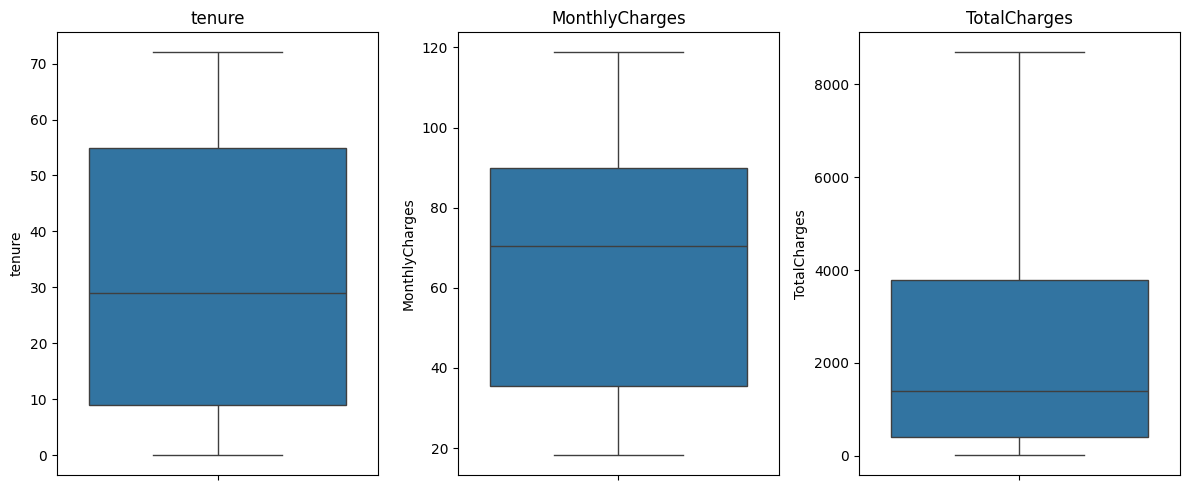

In [21]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(12,5))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Boxplots were generated for tenure, MonthlyCharges, and TotalCharges. Some extreme values are present, particularly in MonthlyCharges and TotalCharges. These values represent genuine customer behavior and spending patterns rather than data entry errors; therefore, no outliers were removed.

In [23]:
# Feature 1: Revenue Per Month
df['RevenuePerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

# Feature 2: Long Term Customer
df['LongTermCustomer'] = np.where(df['tenure'] > 24, 1, 0)

# Feature 3: High Spender
df['HighSpender'] = np.where(
    df['MonthlyCharges'] > df['MonthlyCharges'].median(),
    1,
    0
)

# Feature 4: Average Charges Per Year
df['ChargesPerYear'] = df['TotalCharges'] / ((df['tenure'] / 12) + 1)

# Feature 5: Senior Citizen Flag
df['SeniorCitizenFlag'] = df['SeniorCitizen']

# Feature 6: Contract Type Risk
df['ContractRisk'] = np.where(
    df['Contract'] == 'Month-to-month',
    1,
    0
)

# Feature 7: Electronic Payment User
df['ElectronicPayment'] = np.where(
    df['PaymentMethod'] == 'Electronic check',
    1,
    0
)

# Feature 8: Service Count
service_cols = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['ServiceCount'] = (
    (df[service_cols] != 'No').sum(axis=1)
)

# Preview New Features
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TotalCharges,Churn,RevenuePerMonth,LongTermCustomer,HighSpender,ChargesPerYear,SeniorCitizenFlag,ContractRisk,ElectronicPayment,ServiceCount
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,29.85,No,14.925000,0,0,27.553846,0,1,1,3
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,1889.50,No,53.985714,1,0,492.913043,0,0,0,4
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,108.15,Yes,36.050000,0,0,92.700000,0,1,0,4
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,1840.75,No,40.016304,1,0,387.526316,0,0,0,5
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,151.65,Yes,50.550000,0,1,129.985714,0,1,1,2


In [24]:
# Check Newly Created Features

new_features = [
    'RevenuePerMonth',
    'LongTermCustomer',
    'HighSpender',
    'ChargesPerYear',
    'SeniorCitizenFlag',
    'ContractRisk',
    'ElectronicPayment',
    'ServiceCount'
]

df[new_features].head()

,RevenuePerMonth,LongTermCustomer,HighSpender,ChargesPerYear,SeniorCitizenFlag,ContractRisk,ElectronicPayment,ServiceCount
0,14.925000,0,0,27.553846,0,1,1,3
1,53.985714,1,0,492.913043,0,0,0,4
2,36.050000,0,0,92.700000,0,1,0,4
3,40.016304,1,0,387.526316,0,0,0,5
4,50.550000,0,1,129.985714,0,1,1,2


Several behavioral and business-oriented features were created to improve customer analysis and churn prediction. These features capture customer spending patterns, contract risk, service usage behavior, payment preferences, and customer loyalty indicators.

Churn Distribution

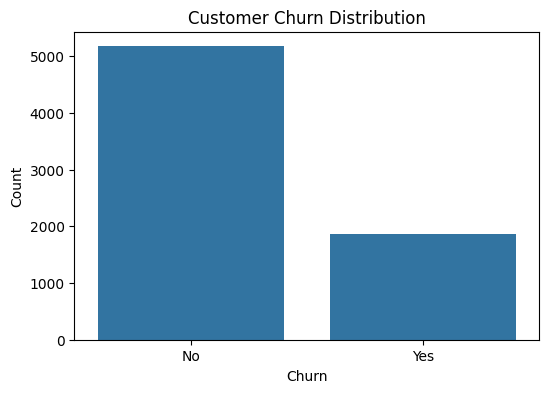

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')

plt.show()

Revenue Trend

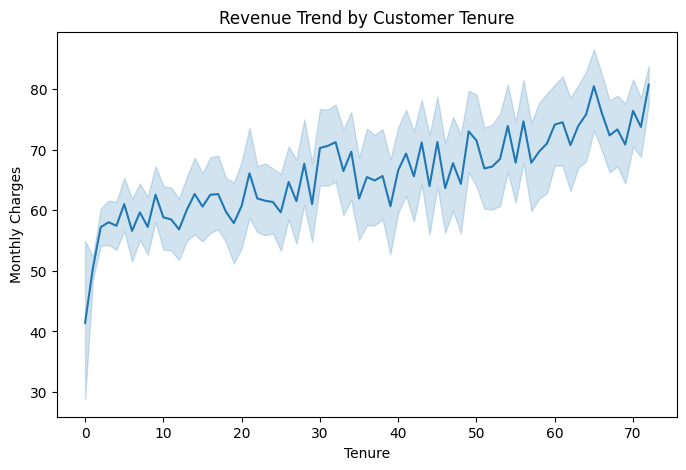

In [26]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x='tenure',
    y='MonthlyCharges',
    data=df
)

plt.title('Revenue Trend by Customer Tenure')
plt.xlabel('Tenure')
plt.ylabel('Monthly Charges')

plt.show()

Customer Segmentation Chart

In [28]:
# Customer Segmentation

conditions = [
    df['MonthlyCharges'] > 80,
    (df['MonthlyCharges'] >= 40) & (df['MonthlyCharges'] <= 80),
    df['MonthlyCharges'] < 40
]

values = [
    'High Value',
    'Medium Value',
    'Low Value'
]

df['CustomerSegment'] = np.select(
    conditions,
    values,
    default='Medium Value'
)

In [29]:
df['CustomerSegment'].value_counts()

,count
CustomerSegment,
High Value,2666
Medium Value,2540
Low Value,1837


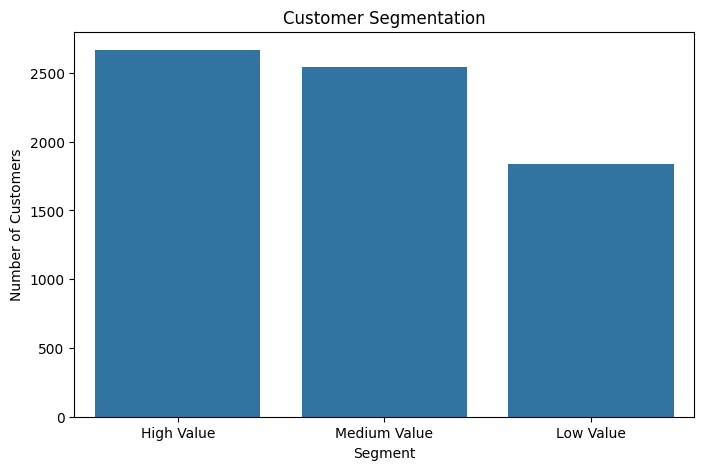

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='CustomerSegment',
    data=df,
    order=['High Value','Medium Value','Low Value']
)

plt.title('Customer Segmentation')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')

plt.show()

Correlation Heatmap

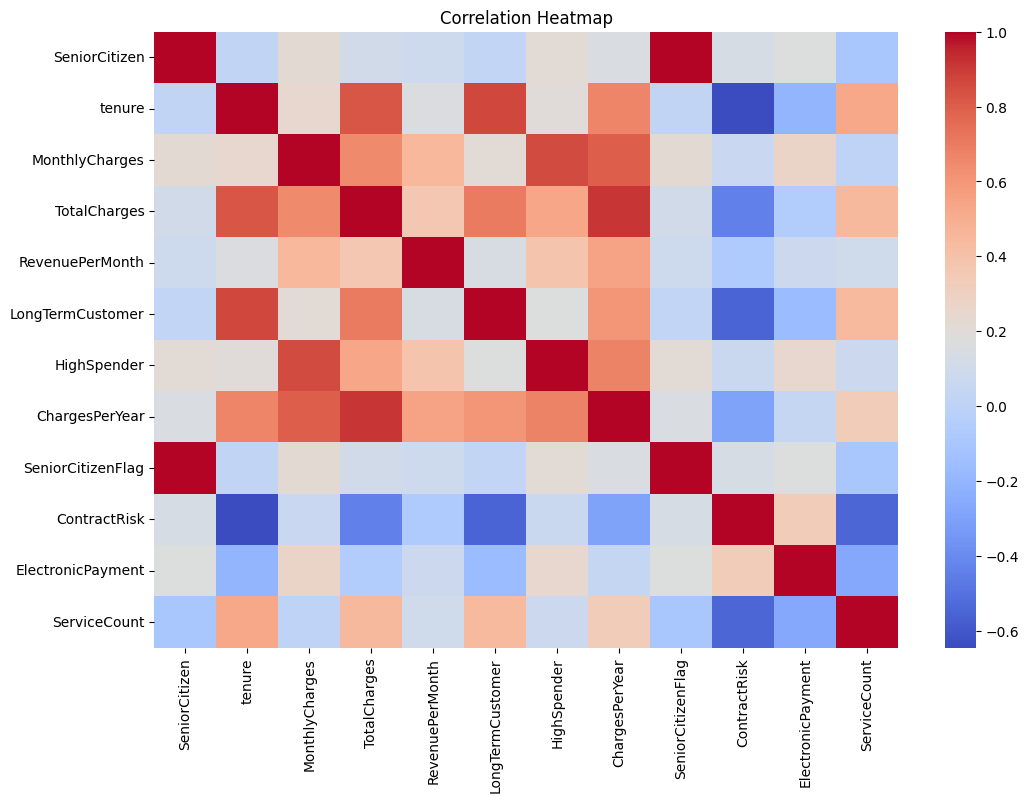

In [31]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

Contract Type vs Churn

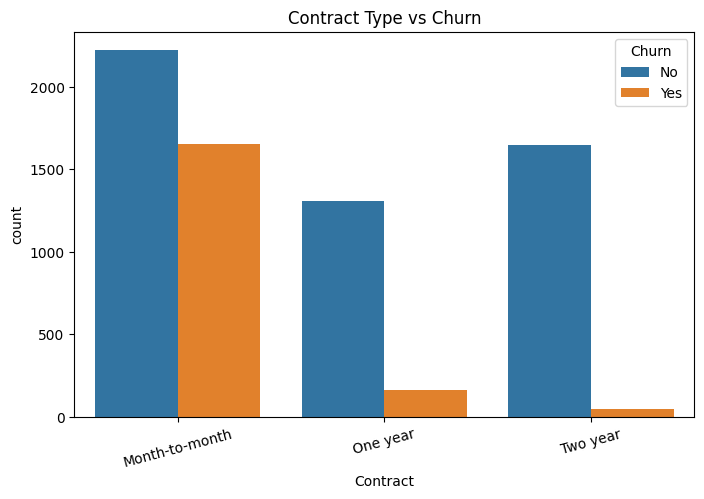

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title('Contract Type vs Churn')

plt.xticks(rotation=15)

plt.show()

Payment Method vs Churn

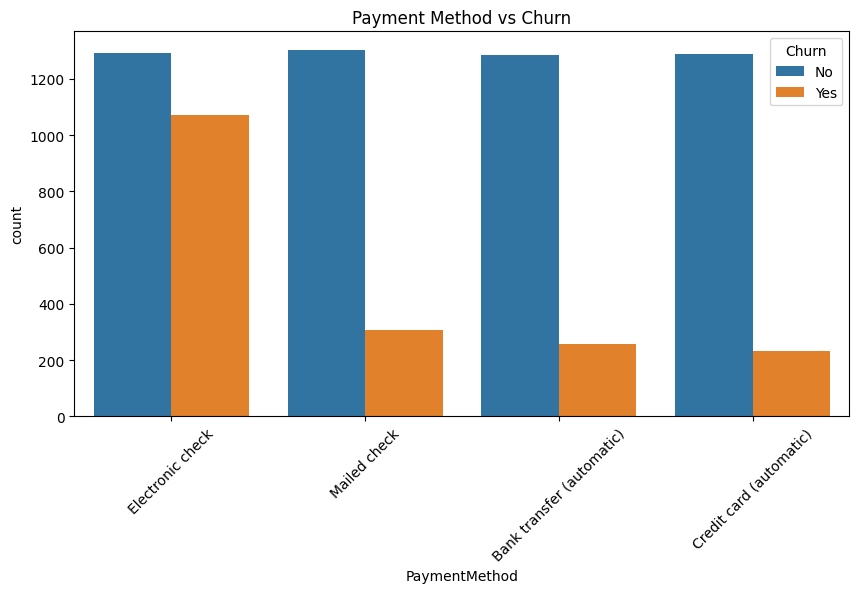

In [33]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df
)

plt.title('Payment Method vs Churn')

plt.xticks(rotation=45)

plt.show()

Monthly Charges vs Churn

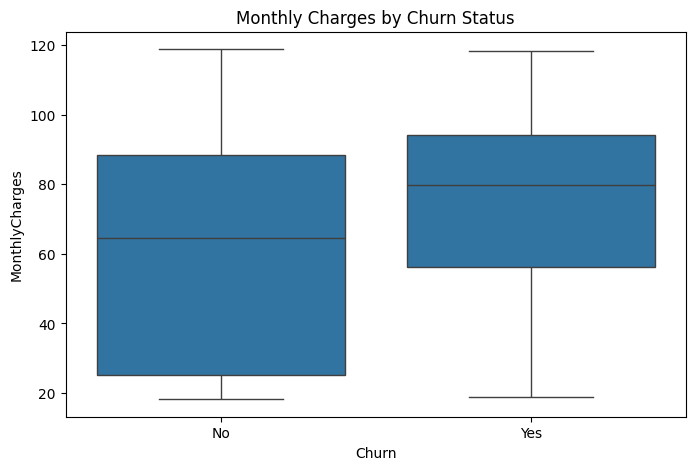

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title('Monthly Charges by Churn Status')

plt.show()

### Visualization Insights

- Customers with month-to-month contracts show higher churn rates.
- Customers paying higher monthly charges are more likely to churn.
- Electronic check users exhibit a higher tendency to leave.
- Long-term customers generally demonstrate greater retention.
- Customer spending patterns strongly influence churn behavior.

DATA PREPROCESSING

In [36]:
# Remove Customer ID

df.drop('customerID', axis=1, inplace=True)

In [37]:
# Encode Categorical Variables

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [38]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Churn,RevenuePerMonth,LongTermCustomer,HighSpender,ChargesPerYear,SeniorCitizenFlag,ContractRisk,ElectronicPayment,ServiceCount,CustomerSegment
0,0,0,1,0,1,0,1,0,0,2,...,0,14.925000,0,0,27.553846,0,1,1,3,1
1,1,0,0,0,34,1,0,0,2,0,...,0,53.985714,1,0,492.913043,0,0,0,4,2
2,1,0,0,0,2,1,0,0,2,2,...,1,36.050000,0,0,92.700000,0,1,0,4,2
3,1,0,0,0,45,0,1,0,2,0,...,0,40.016304,1,0,387.526316,0,0,0,5,2
4,0,0,0,0,2,1,0,1,0,0,...,1,50.550000,0,1,129.985714,0,1,1,2,2


In [39]:
df.dtypes

,0
gender,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,int64
InternetService,int64
OnlineSecurity,int64
OnlineBackup,int64


In [40]:
# Features and Target Variable

X = df.drop('Churn', axis=1)
y = df['Churn']

In [41]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (5634, 28)
Testing Data Shape: (1409, 28)


Logistic Regression Model

In [ ]:
# Logistic Regression Model

lr_model = LogisticRegression(
    max_iter=5000,
    solver='liblinear',
    random_state=42
)

lr_model.fit(X_train, y_train)

In [48]:
y_pred_lr = lr_model.predict(X_test)

Evaluation Metrics

In [49]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.8133427963094393
Precision: 0.6785714285714286
Recall   : 0.5603217158176944
F1 Score : 0.6138032305433186


Classification Report

In [50]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1036
           1       0.68      0.56      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.75      1409
weighted avg       0.81      0.81      0.81      1409



Confusion Matrix

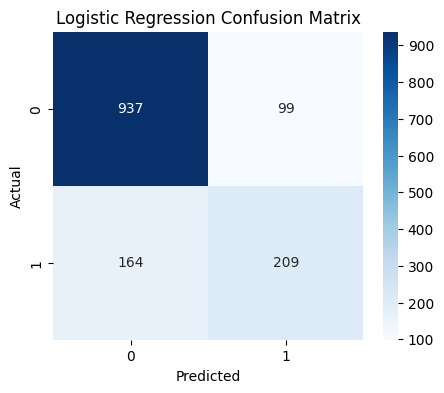

In [51]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

Random Forest Model

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

In [53]:
y_pred_rf = rf_model.predict(X_test)

In [54]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.794180269694819
Precision: 0.654275092936803
Recall   : 0.4718498659517426
F1 Score : 0.5482866043613707


In [55]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.65      0.47      0.55       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



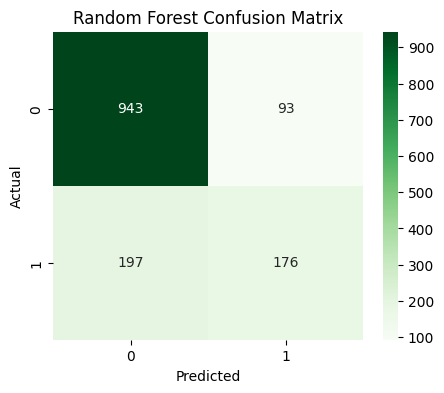

In [56]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [57]:
rf_probs = rf_model.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, rf_probs)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.8393387642717401


MODEL COMPARISON


In [58]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.813343,0.678571,0.560322,0.613803
1,Random Forest,0.794180,0.654275,0.471850,0.548287


Churn Probability Prediction

In [59]:
df['ChurnProbability'] = rf_model.predict_proba(X)[:,1]

df[['ChurnProbability']].head()

,ChurnProbability
0,0.335
1,0.005
2,0.800
3,0.020
4,0.790


Risk Categories

In [60]:
df['RiskCategory'] = pd.cut(
    df['ChurnProbability'],
    bins=[0, 0.3, 0.7, 1],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

df['RiskCategory'].value_counts()

,count
RiskCategory,
Low Risk,4173
High Risk,1381
Medium Risk,700


Risk Distribution Chart

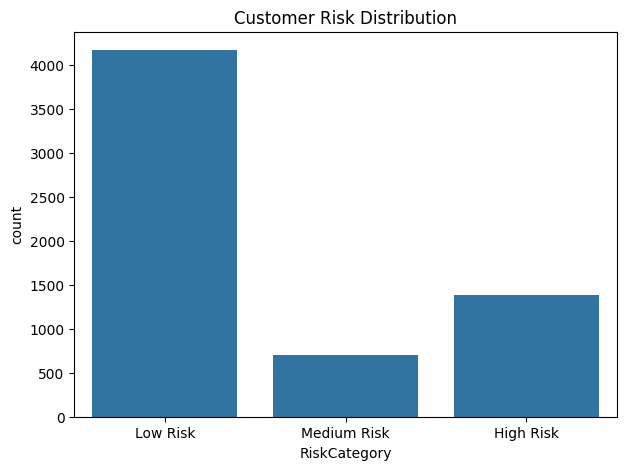

In [61]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='RiskCategory',
    data=df,
    order=['Low Risk', 'Medium Risk', 'High Risk']
)

plt.title('Customer Risk Distribution')
plt.show()

## Business Insights

### Top Churn Reasons
- Customers with month-to-month contracts exhibit higher churn rates.
- Higher monthly charges are associated with increased churn probability.
- Customers with shorter tenure are more likely to leave the company.

### High-Risk Customer Characteristics
- Short customer tenure.
- High monthly subscription charges.
- Electronic check payment method.
- Month-to-month contracts.

### Revenue Impact
- High-risk customers represent potential future revenue loss.
- Retention strategies should focus on customers identified as medium and high risk.

### Recommended Actions
- Encourage long-term contracts through incentives.
- Offer loyalty rewards to long-tenure customers.
- Provide targeted retention offers to high-risk customers.
- Improve customer support engagement for at-risk segments.

## Model Recommendation

Based on the evaluation metrics, Random Forest demonstrated stronger predictive performance and achieved a ROC-AUC score of approximately 0.84. Therefore, Random Forest is recommended as the preferred model for churn prediction in this project.

## Conclusion

This project successfully analyzed customer behavior and developed churn prediction models using machine learning techniques. Customer segmentation, feature engineering, and predictive analytics provided valuable insights into customer retention patterns. Among the evaluated models, Random Forest demonstrated strong predictive capability and achieved a ROC-AUC score of approximately 0.84, making it suitable for identifying customers at risk of churn and supporting data-driven business decisions.